In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

refs = ['Ruminococcus_torques_ATCC_27756', 'Ruminococcus_gnavus_ATCC_29149', 'Anaerostipes_hadrus_ATCC_29173', 'Agathobacter_rectalis_ATCC_33656']
reflabels = [r'$\mathit{Ruminococcus\ torques}$ ATCC 27756', r'$\mathit{Ruminococcus\ gnavus}$ ATCC 29149', r'$\mathit{Anaerostipes\ hadrus}$ ATCC 29173', r'$\mathit{Agathobacter\ rectalis}$ ATCC 33656']

In [2]:
### Format number to show 2 significant figures (no scientific notation)

import math

def format_2sf(val):
    if val == 0:
        return "0"
    elif val < 10:
        return f"{val:.1f}"
    else:
        order = int(math.floor(math.log10(abs(val))))
        scale = 10 ** (order - 1)
        rounded = round(val / scale) * scale
        return f"{rounded:.0f}"

### Fig. 3D: induction of VFC 1-4 prophages *in vitro*

C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3758488078.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3758488078.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3758488078.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3758488078.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

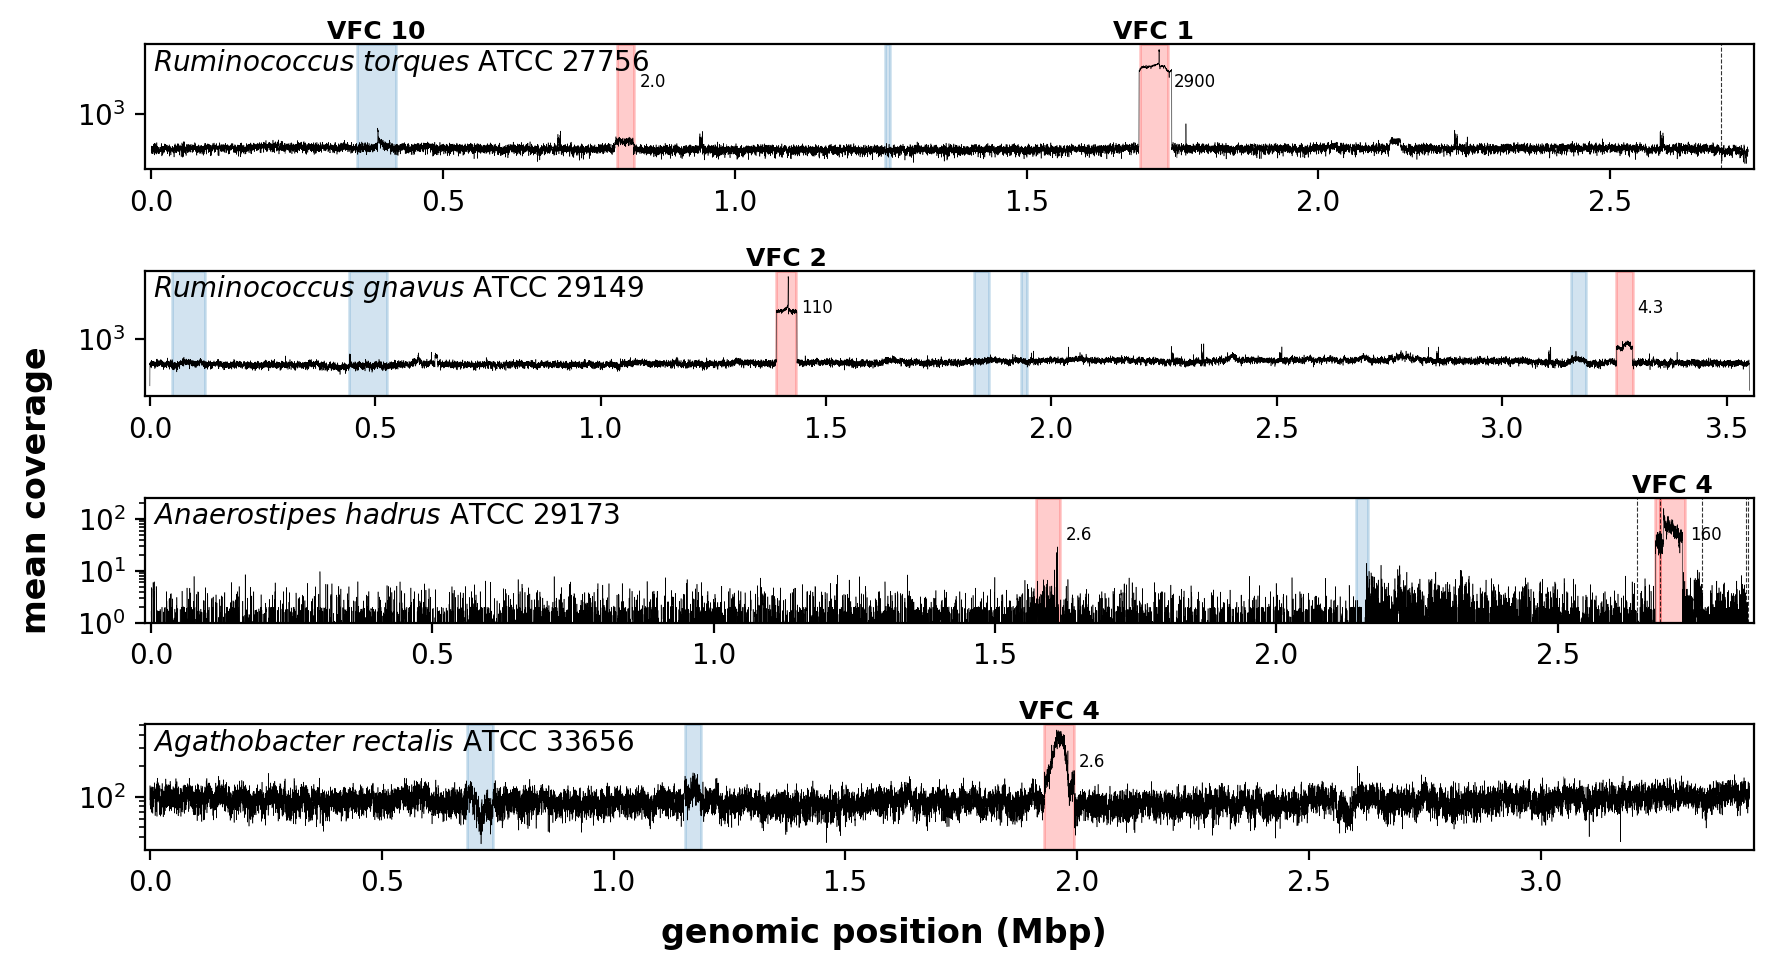

In [3]:
mitcol = 'mitC'

foldinductioncol = f'fold_induction_{mitcol}'

import matplotlib.transforms as mtransforms

fig, axes = plt.subplots(4, figsize=(9, 5), dpi=200)

for i, (ref, reflabel) in enumerate(zip(refs, reflabels)):
    df = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_depth.tsv', sep='\t')
    df_contigs = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_contig-info.tsv', sep='\t')
    df_prophage = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_prophage-info.tsv', sep='\t')
 
    # Rolling mean in 100-bp windows
    df1 = df.loc[:, mitcol].rolling(100, min_periods=1, center=True).mean()
    df2 = df1.iloc[::100]
    
    sns.lineplot(data=df2, linewidth=0.2, ax=axes[i], color='black')
    axes[i].set(yscale='log') # log scale
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].annotate(reflabel, xy=(0.005,0.98), xycoords='axes fraction', va='top', ha='left')
    
    trans = mtransforms.blended_transform_factory(axes[i].transData, axes[i].transAxes)

    # Shade prophage regions
    for id, row in df_prophage.iterrows():
        axes[i].axvspan(
            row.cumstart, row.cumend,
            color='red' if row[foldinductioncol] > 1.75 else 'C0',
            alpha=0.2, edgecolor=None
        )
        if row[foldinductioncol] > 1.75:
            xpos = row.cumend + 1e4
            if not (ref=='Anaerostipes_hadrus_ATCC_29173' and id==2): # same prophage as the VFC 4 one, skip label
                axes[i].text(
                    xpos, 0.7, format_2sf(row[foldinductioncol]),
                    ha='left', va='center', fontsize=6, transform=trans
                )

    # Genome assembly boundaries
    for id, row in df_contigs.iterrows():
        if id > 0:
            axes[i].axvline(x=row.cum_sum, color='black', linewidth=0.4, alpha=0.8, linestyle='--')
    
    for id, row in df_prophage.iterrows():
        if row.VFC <= 12:
            axes[i].text((row.cumstart + row.cumend)/2, 1, f'VFC {int(row.VFC)}',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             transform=trans)
    
    x_min = df_contigs['cum_sum'].min()
    x_max = (df_contigs['cum_sum'] + df_contigs['contig_len']).max()
    axes[i].set_xlim(x_min-1e4, x_max+1e4)

    y1, y2 = axes[i].get_ylim()
    axes[i].set_ylim(max(1,y1), y2) # log scale


for ax in axes:
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])

fig.supxlabel('genomic position (Mbp)', y=0.04, weight='bold')
fig.supylabel('mean coverage', weight='bold')

plt.tight_layout()

### Supplementary Fig. 25: spontaneous induction of VFC 1-4 prophages *in vitro*

C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\2494669623.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\2494669623.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\2494669623.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\2494669623.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

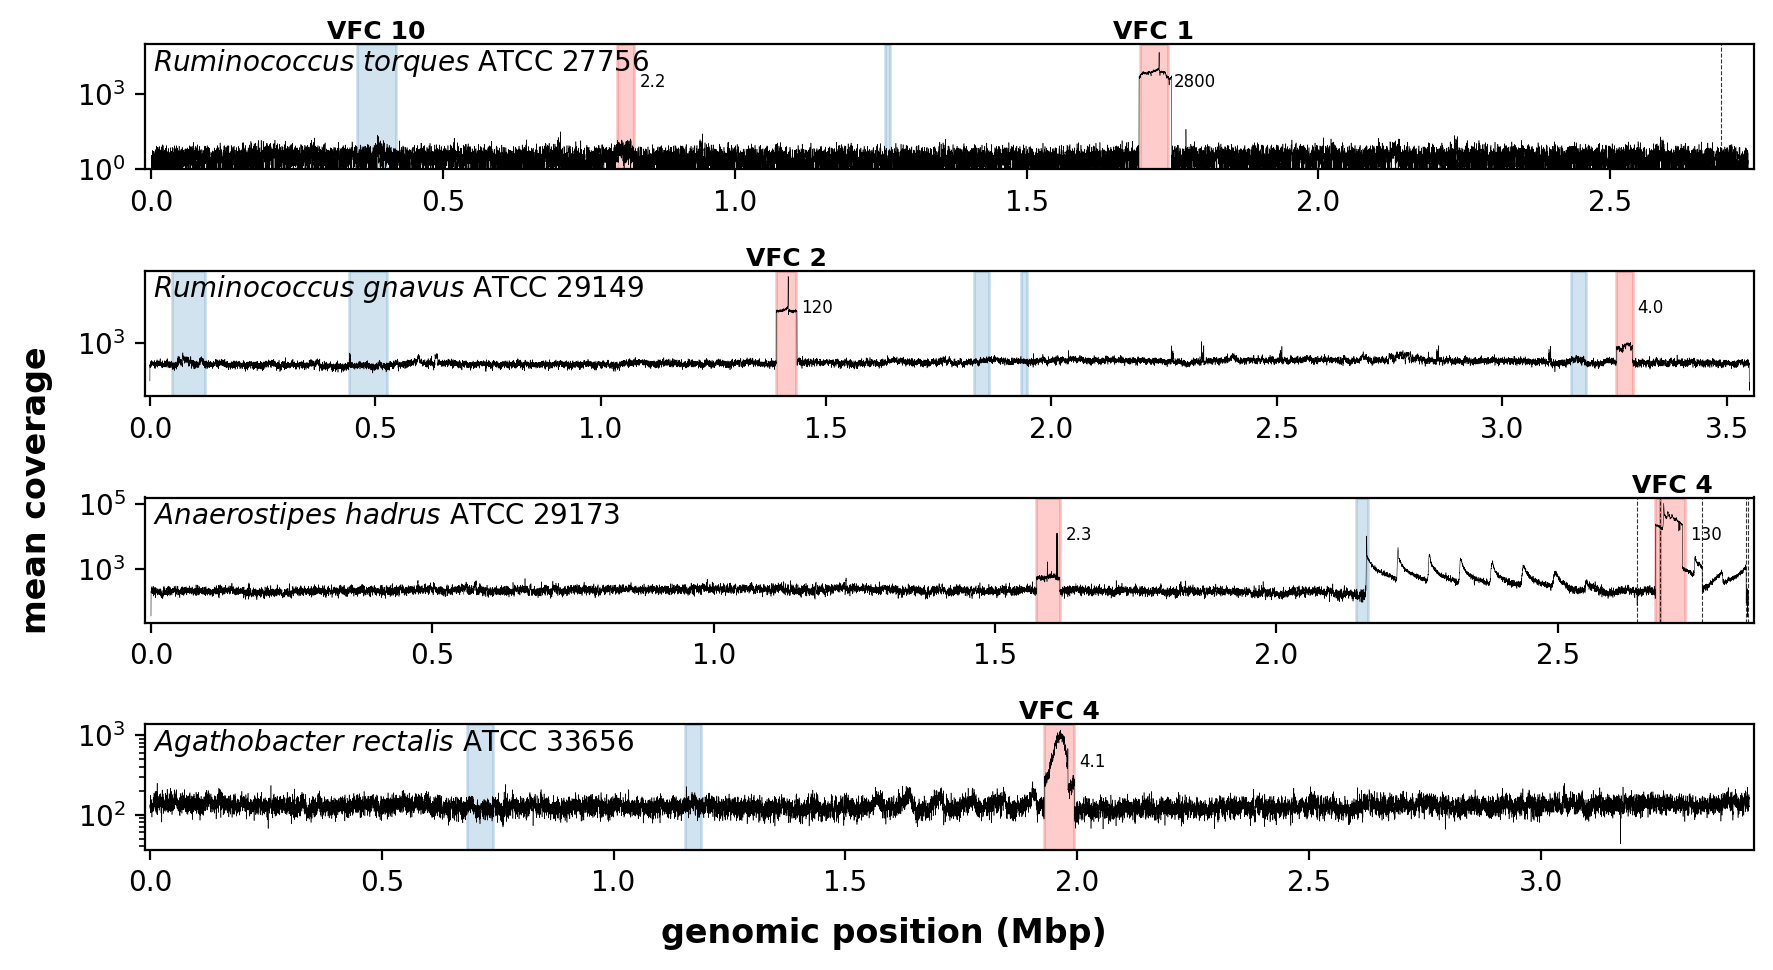

In [4]:
mitcol = 'nomitC'

foldinductioncol = f'fold_induction_{mitcol}'

import matplotlib.transforms as mtransforms

fig, axes = plt.subplots(4, figsize=(9, 5), dpi=200)

for i, (ref, reflabel) in enumerate(zip(refs, reflabels)):
    df = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_depth.tsv', sep='\t')
    df_contigs = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_contig-info.tsv', sep='\t')
    df_prophage = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_prophage-info.tsv', sep='\t')
 
    # Rolling mean in 100-bp windows
    df1 = df.loc[:, mitcol].rolling(100, min_periods=1, center=True).mean()
    df2 = df1.iloc[::100]
    
    sns.lineplot(data=df2, linewidth=0.2, ax=axes[i], color='black')
    axes[i].set(yscale='log') # log scale
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].annotate(reflabel, xy=(0.005,0.98), xycoords='axes fraction', va='top', ha='left')
    
    trans = mtransforms.blended_transform_factory(axes[i].transData, axes[i].transAxes)

    # Shade prophage regions
    for id, row in df_prophage.iterrows():
        axes[i].axvspan(
            row.cumstart, row.cumend,
            color='red' if row[foldinductioncol] > 1.75 else 'C0',
            alpha=0.2, edgecolor=None
        )
        if row[foldinductioncol] > 1.75:
            xpos = row.cumend + 1e4
            if not (ref=='Anaerostipes_hadrus_ATCC_29173' and id==2): # same prophage as the VFC 4 one, skip label
                axes[i].text(
                    xpos, 0.7, format_2sf(row[foldinductioncol]),
                    ha='left', va='center', fontsize=6, transform=trans
                )

    # Genome assembly boundaries
    for id, row in df_contigs.iterrows():
        if id > 0:
            axes[i].axvline(x=row.cum_sum, color='black', linewidth=0.4, alpha=0.8, linestyle='--')
    
    for id, row in df_prophage.iterrows():
        if row.VFC <= 12:
            axes[i].text((row.cumstart + row.cumend)/2, 1, f'VFC {int(row.VFC)}',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             transform=trans)
    
    x_min = df_contigs['cum_sum'].min()
    x_max = (df_contigs['cum_sum'] + df_contigs['contig_len']).max()
    axes[i].set_xlim(x_min-1e4, x_max+1e4)

    y1, y2 = axes[i].get_ylim()
    axes[i].set_ylim(max(1,y1), y2) # log scale


for ax in axes:
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_xticklabels([f'{x/1e6:.1f}' for x in ax.get_xticks()])

fig.supxlabel('genomic position (Mbp)', y=0.04, weight='bold')
fig.supylabel('mean coverage', weight='bold')

plt.tight_layout()

### Supplementary Fig. 26A: zoomed-in versions of VFC 1-4 prophage regions

C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3409742529.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.2f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3409742529.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.2f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3409742529.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x/1e6:.2f}' for x in ax.get_xticks()])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43764\3409742529.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

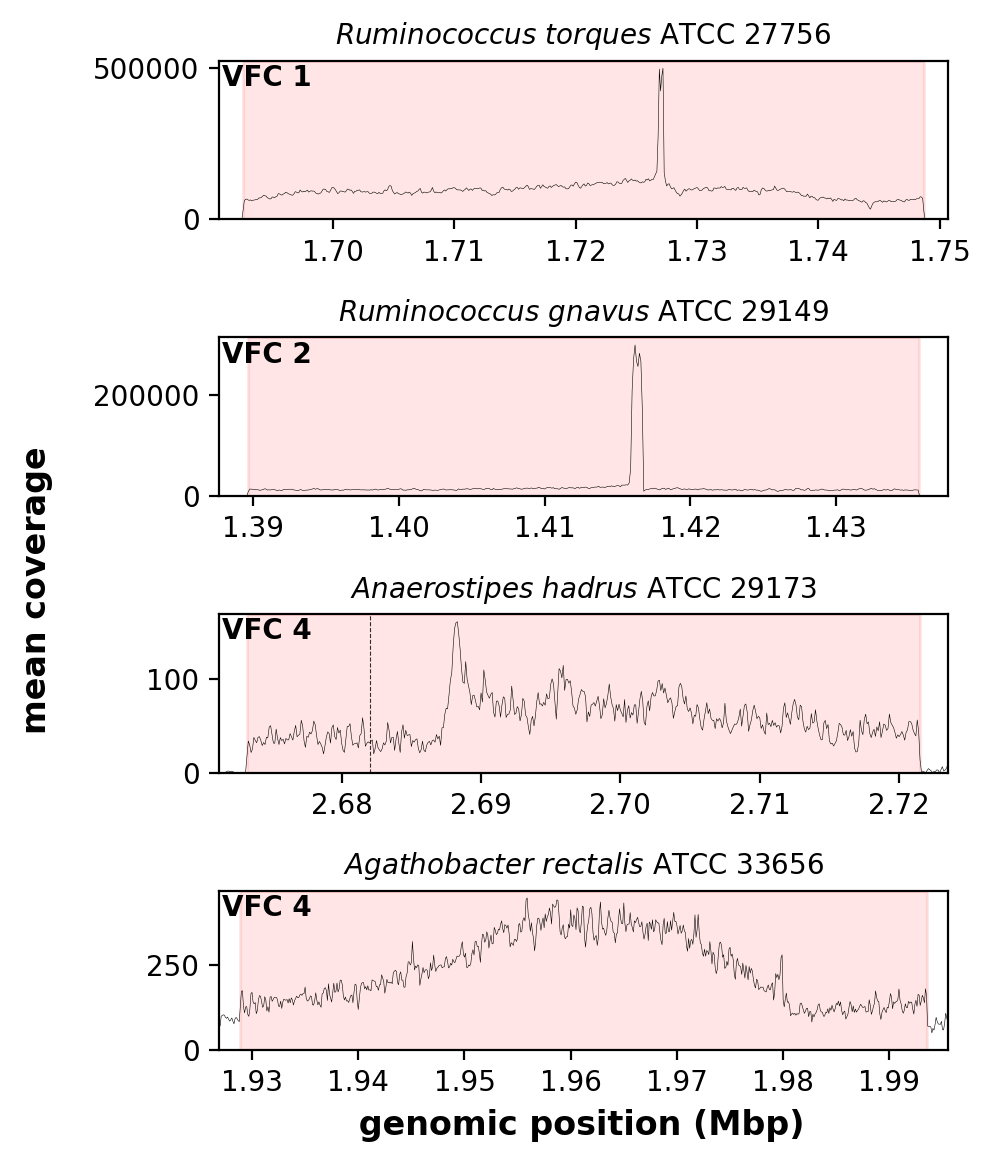

In [5]:
mitcol = 'mitC'

foldinductioncol = f'fold_induction_{mitcol}'

# Pick out the prophages belonging to these VFCs to plot
vfcs = [1, 2, 4, 4]

fig, axes = plt.subplots(4, figsize=(5, 6), dpi=200)

for i, (ref, reflabel, vfc) in enumerate(zip(refs, reflabels, vfcs)):
    df = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_depth.tsv', sep='\t')
    df_contigs = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_contig-info.tsv', sep='\t')
    df_prophage = pd.read_csv(f'../data/prophage_induction_readmapping/{ref}_prophage-info.tsv', sep='\t')
 
    # Rolling mean in 100-bp windows
    df1 = df.loc[:, mitcol].rolling(100, min_periods=1, center=True).mean()
    df2 = df1.iloc[::100]
    
    sns.lineplot(data=df2, linewidth=0.2, ax=axes[i], color='black')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    prophage_row = df_prophage[df_prophage['VFC'] == vfc].iloc[0]

    axes[i].annotate(f'VFC {int(prophage_row.VFC)}', xy=(0.005,0.98), xycoords='axes fraction', va='top', ha='left', fontweight='bold')
    
    axes[i].set_title(reflabel, fontsize=10)
    
    axes[i].axvspan(
        prophage_row.replication_cumstart, prophage_row.replication_cumend,
        color='red', alpha=0.1, edgecolor=None
    )
    
    # Genome assembly boundaries
    for id, row in df_contigs.iterrows():
        if id > 0:
            axes[i].axvline(x=row.cum_sum, color='black', linewidth=0.4, alpha=0.8, linestyle='--')

    axes[i].set_xlim(prophage_row.replication_cumstart - 2e3, prophage_row.replication_cumend + 2e3)

    y1, y2 = axes[i].get_ylim()
    axes[i].set_ylim(0, y2) # linear scale

for ax in axes:
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_xticklabels([f'{x/1e6:.2f}' for x in ax.get_xticks()])

fig.supxlabel('              genomic position (Mbp)', y=0.04, weight='bold')
fig.supylabel('mean coverage', weight='bold')

plt.tight_layout()